In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, roc_curve

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sonialikhan/heart-attack-analysis-and-prediction-dataset/o2Saturation.csv
/kaggle/input/datasets/sonialikhan/heart-attack-analysis-and-prediction-dataset/heart.csv


# load dataset and basic data

In [2]:
df = pd.read_csv("/kaggle/input/datasets/sonialikhan/heart-attack-analysis-and-prediction-dataset/heart.csv")

In [3]:
df.shape

(303, 14)

In [4]:
df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
df.tail()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [6]:
df.describe()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None


In [8]:
df.columns

Index(['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh',
       'exng', 'oldpeak', 'slp', 'caa', 'thall', 'output'],
      dtype='object')

# missing value problem

In [9]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64


kayıp veri yoktur

# categorical and numerical feature analysis

## categorical

In [10]:
categorical_list = ['sex', 'cp', 'fbs', 'restecg', 'exng', 'slp', 'caa','thall', 'output']

df_categorical = df.loc[:, categorical_list]

df_categorical

,sex,cp,fbs,restecg,exng,slp,caa,thall,output
0,1,3,1,0,0,0,0,1,1
1,1,2,0,1,0,0,0,2,1
2,0,1,0,0,0,2,0,2,1
3,1,1,0,1,0,2,0,2,1
4,0,0,0,1,1,2,0,2,1
...,...,...,...,...,...,...,...,...,...
298,0,0,0,1,1,1,0,3,0
299,1,3,0,1,0,1,0,3,0
300,1,0,1,1,0,1,2,3,0
301,1,0,0,1,1,1,1,3,0


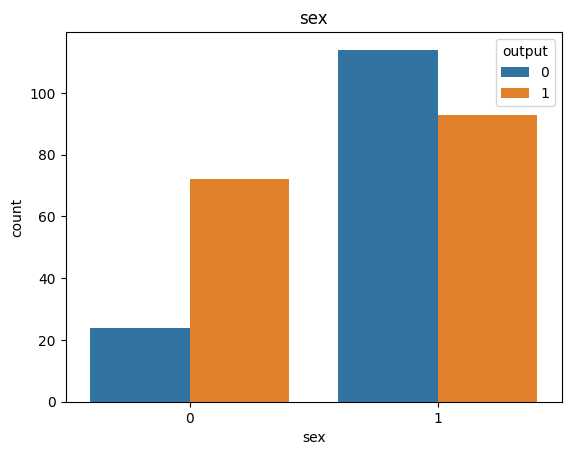

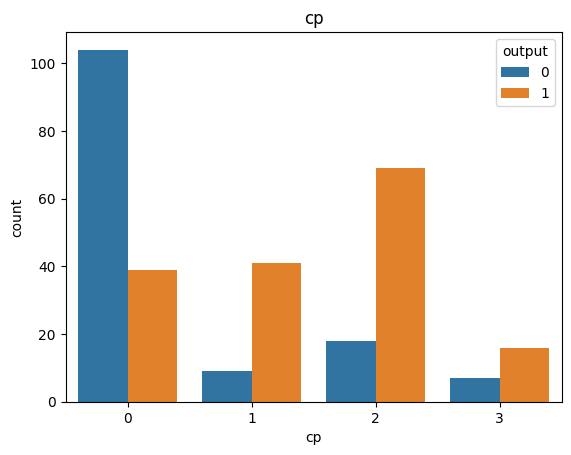

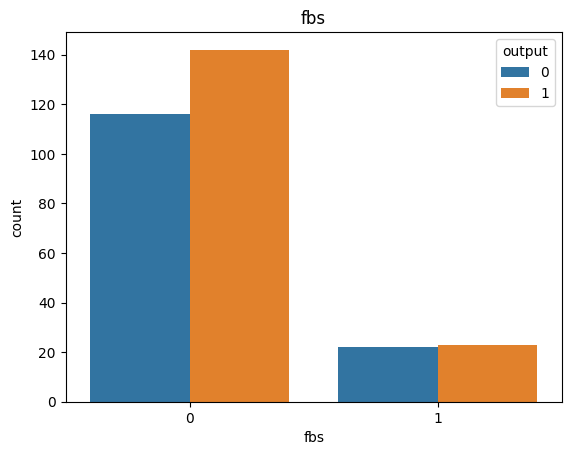

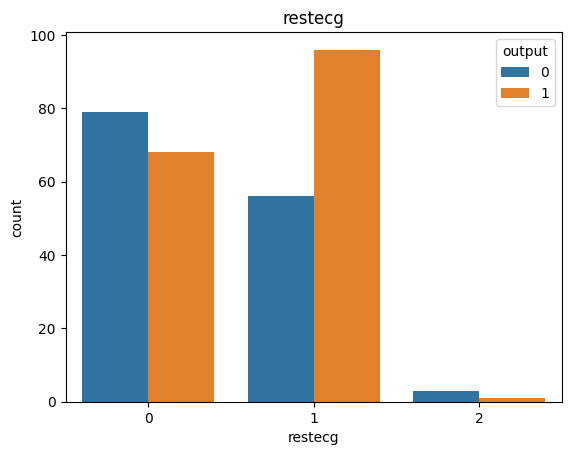

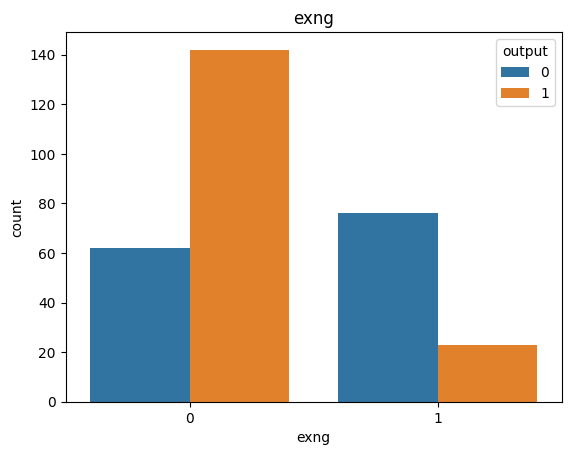

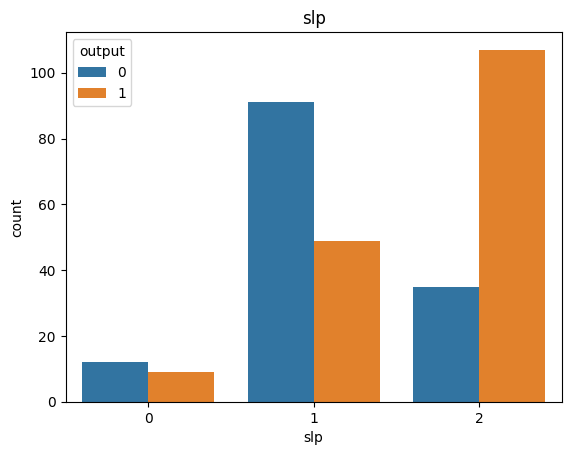

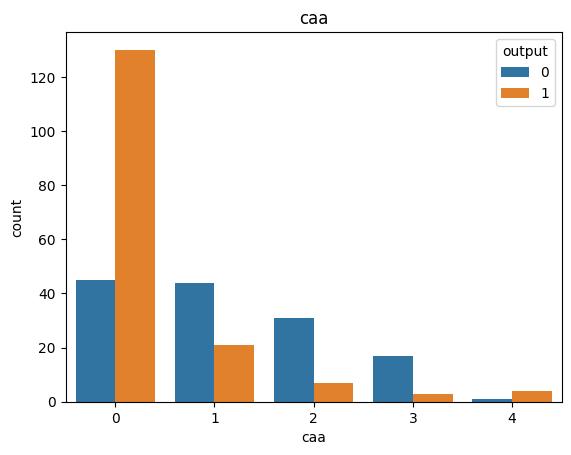

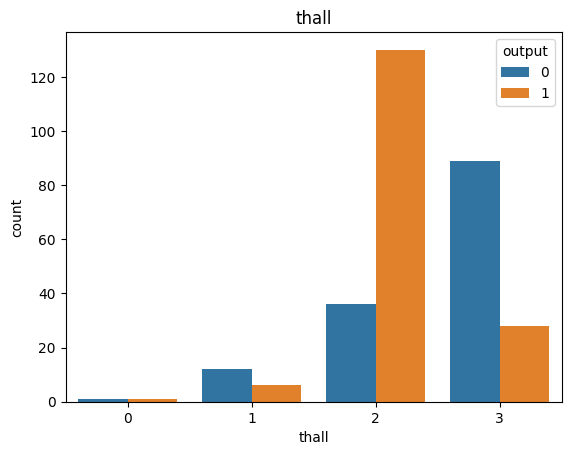

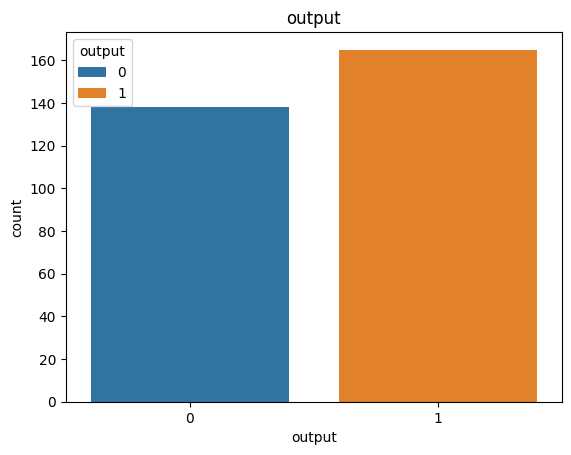

In [11]:
for i in categorical_list:
    plt.figure()
    sns.countplot(x=i, data = df_categorical, hue = "output")
    plt.title(i)

* **sex:**
  * 0 cinsiyetinde kalp krizi geçirme olasılığı daha yüksek
  * 1 cinsiyetinde kalp krizi geçirmeme olasılığı daha yüksek
    
    
* **output:** 1 sayısı yaklaşık 160, 0 ise 140. yani oransal olatak yakın


## numeric

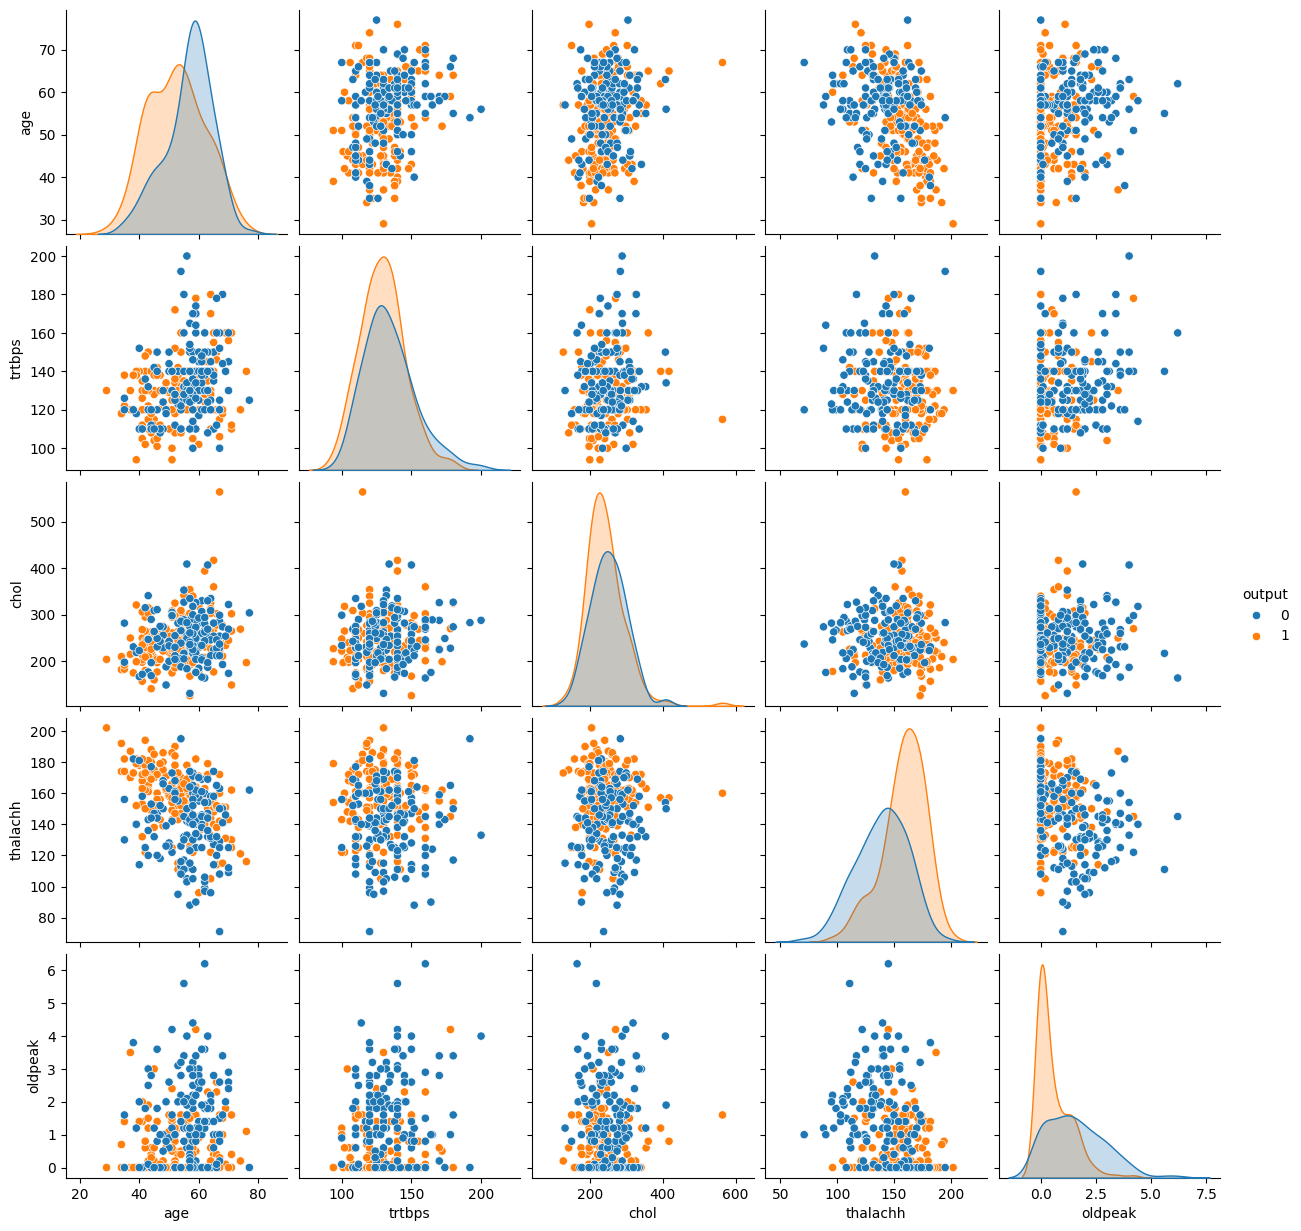

In [12]:
numeric_list = ['age', 'trtbps', 'chol', 'thalachh', 'oldpeak', 'output']
df_numeric = df.loc[:, numeric_list]
sns.pairplot(df_numeric, hue="output", diag_kind = "kde")
plt.show()

# EDA

box, swarm, cat, correlatilation analysis

## standardization

In [13]:
scaler = StandardScaler()
scaled_array = scaler.fit_transform(df[numeric_list[:-1]])

In [14]:
df_dummy = pd.DataFrame(scaled_array, columns = numeric_list[:-1])

In [15]:
df_dummy = pd.concat([df_dummy, df.loc[:, "output"]], axis = 1)

## box plot analysis

In [16]:
data_melted = pd.melt(df_dummy, id_vars="output", var_name = "features", value_name = "value")

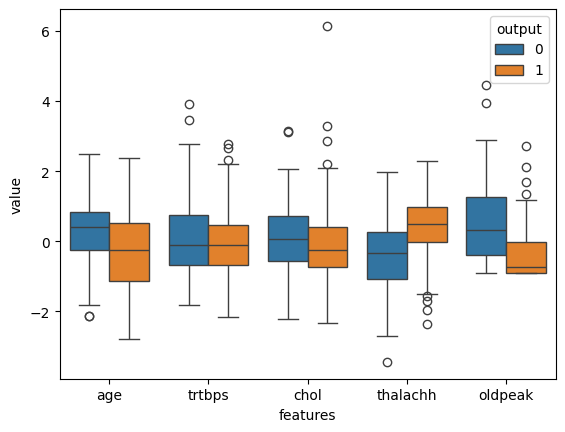

In [17]:
plt.figure()
sns.boxplot(x="features", y = "value", hue="output", data = data_melted)
plt.show()

* **age:**
  * 0ın medyanı daha yüksek, 1in medyanı daha düşük
  * 1 tane outliner söz konusu

* **chol:**
  * çok yüksekte bir outliner var

* **thalachh:**
  * 1 ve 0 arasında çok fark var

## swarm plot

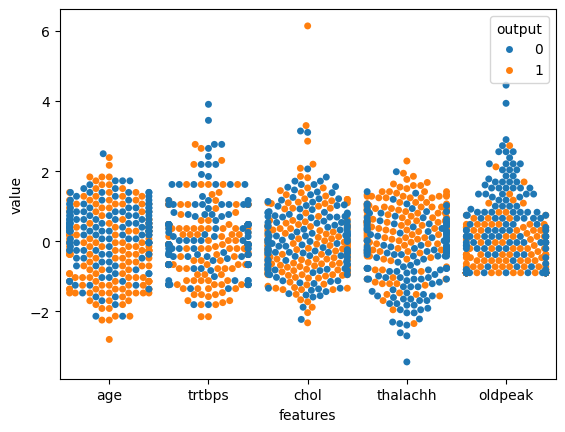

In [18]:
plt.figure()
sns.swarmplot(x="features", y = "value", hue="output", data = data_melted)
plt.show()

## cat plot

<Figure size 640x480 with 0 Axes>

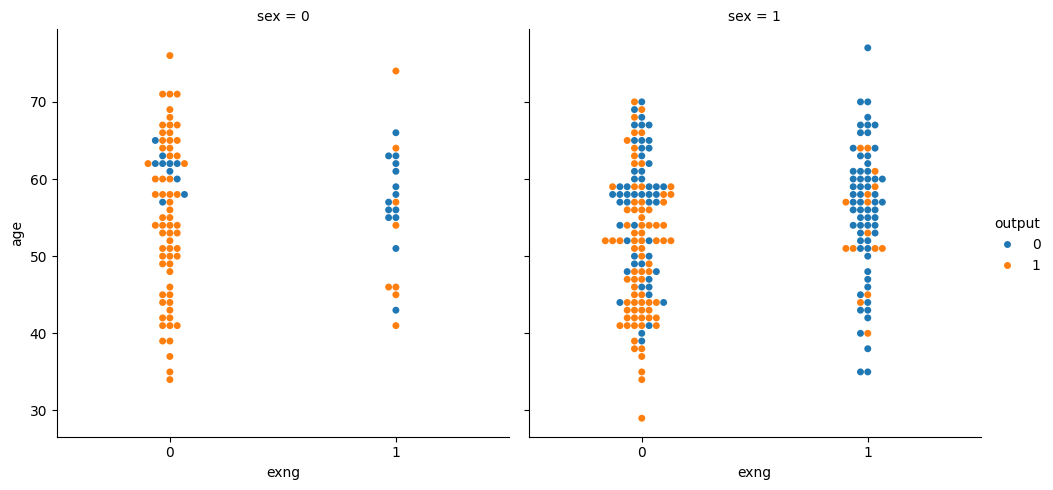

In [19]:
plt.figure()
sns.catplot(x="exng", y="age", hue="output", col="sex", kind="swarm", data=df)
plt.show()

<Figure size 640x480 with 0 Axes>

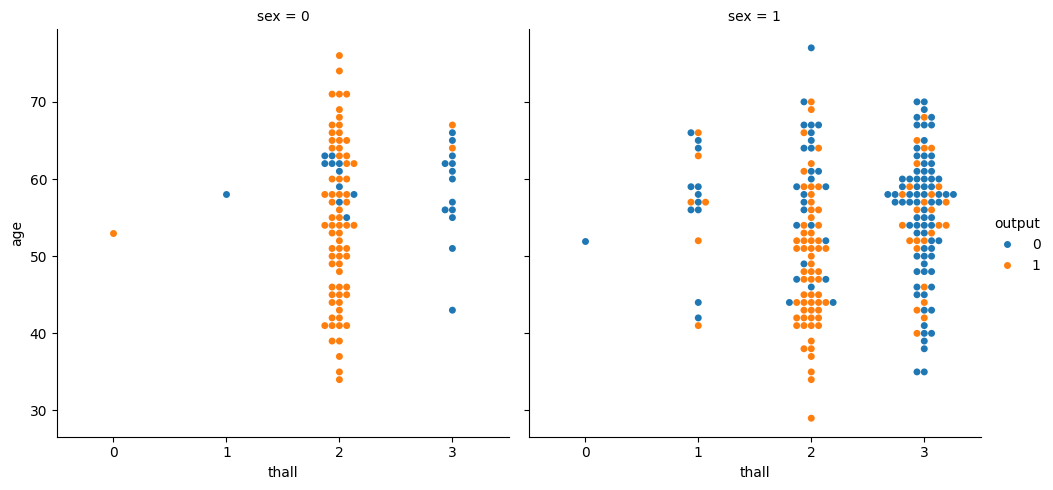

In [20]:
plt.figure()
sns.catplot(x="thall", y="age", hue="output", col="sex", kind="swarm", data=df)
plt.show()

## correlation

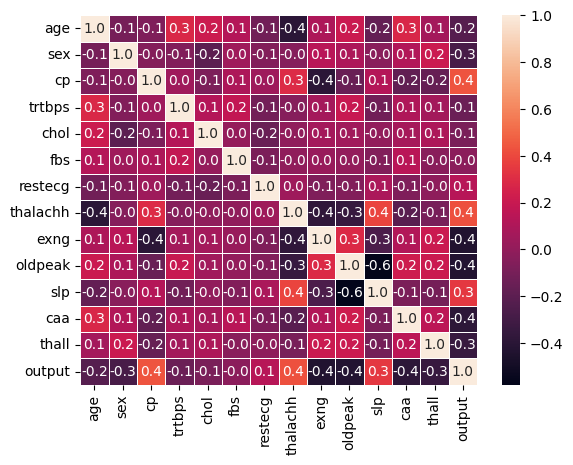

In [21]:
plt.figure()
sns.heatmap(df.corr(), annot = True, fmt=".1f", linewidths=0.7)
plt.show()

# outlier detection

In [22]:
numeric_list = ['age', 'trtbps', 'chol', 'thalachh', 'oldpeak']
df_numeric = df.loc[:, numeric_list]

* IQR = %75 - %25
* upper bound = %75 + 2.5*IQR
* lower bound = %25 + 2.5*IQR

upper ve lower dışında kalan değerler outlier

In [23]:
for i in numeric_list: 

    # IQR
    Q1 = np.percentile(df.loc[:,i], 25)
    Q3 = np.percentile(df.loc[:,i], 75)
    
    IQR = Q3 - Q1

    print(i)
    print(f"\nold shape: {df.loc[:,i].shape}")

    #upper bound
    upper = np.where(df.loc[:,i] >= (Q3 + 2.5*IQR))
    #lower bound
    lower = np.where(df.loc[:,i] <= (Q1- 2.5*IQR))
    
    try:
        df.drop(upper[0], inplace = True)
    except:
        print("Hata")
    
    try:
        df.drop(lower[0], inplace = True)
    except:
        print("Hata")
    print(f"New shape: {df.shape}\n")

age

old shape: (303,)
New shape: (303, 14)

trtbps

old shape: (303,)
New shape: (301, 14)

chol

old shape: (301,)
New shape: (300, 14)

thalachh

old shape: (300,)
New shape: (300, 14)

oldpeak

old shape: (300,)
New shape: (298, 14)



# Modelling

## categorical to numeric 
one hot encoding

In [24]:
df = pd.get_dummies(df, columns = categorical_list[:-1], drop_first = True)

In [25]:
df

,age,trtbps,chol,thalachh,oldpeak,output,sex_1,cp_1,cp_2,cp_3,...,exng_1,slp_1,slp_2,caa_1,caa_2,caa_3,caa_4,thall_1,thall_2,thall_3
0,63,145,233,150,2.3,1,True,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1,37,130,250,187,3.5,1,True,False,True,False,...,False,False,False,False,False,False,False,False,True,False
2,41,130,204,172,1.4,1,False,True,False,False,...,False,False,True,False,False,False,False,False,True,False
3,56,120,236,178,0.8,1,True,True,False,False,...,False,False,True,False,False,False,False,False,True,False
4,57,120,354,163,0.6,1,False,False,False,False,...,True,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,140,241,123,0.2,0,False,False,False,False,...,True,True,False,False,False,False,False,False,False,True
299,45,110,264,132,1.2,0,True,False,False,True,...,False,True,False,False,False,False,False,False,False,True
300,68,144,193,141,3.4,0,True,False,False,False,...,False,True,False,False,True,False,False,False,False,True
301,57,130,131,115,1.2,0,True,False,False,False,...,True,True,False,True,False,False,False,False,False,True


In [26]:
X = df.drop(["output"], axis=1)
y = df[["output"]]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
scaler = StandardScaler()
X_train[numeric_list[:-1]] = scaler.fit_transform(X_train[numeric_list[:-1]])
X_test[numeric_list[:-1]] = scaler.transform(X_test[numeric_list[:-1]])

In [29]:
X_train

,age,trtbps,chol,thalachh,oldpeak,sex_1,cp_1,cp_2,cp_3,fbs_1,...,exng_1,slp_1,slp_2,caa_1,caa_2,caa_3,caa_4,thall_1,thall_2,thall_3
6,0.200164,0.565832,1.024614,0.173300,1.3,False,True,False,False,False,...,False,True,False,False,False,False,False,False,True,False
183,0.418693,-1.136518,-0.278351,0.685134,2.5,True,False,True,False,False,...,False,True,False,True,False,False,False,False,False,True
171,-0.673948,-1.258114,-0.298710,0.813092,1.0,True,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
147,0.637221,1.173814,-0.074763,0.941051,0.9,False,False,False,True,False,...,False,False,True,False,False,False,False,False,True,False
30,-1.438797,-1.562105,-0.929834,0.813092,0.0,False,True,False,False,False,...,False,False,True,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,-1.438797,-1.258114,-1.459164,0.386564,0.0,True,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
71,-0.346156,-2.230885,-0.339428,0.215952,0.0,True,False,True,False,False,...,True,False,True,True,False,False,False,False,False,True
107,-1.001740,0.444236,-0.156198,0.130647,0.2,False,False,False,False,False,...,True,True,False,False,False,False,False,False,True,False
275,-0.236892,-0.346141,-0.644811,0.813092,1.0,True,False,False,False,False,...,False,False,True,False,True,False,False,False,False,True


In [30]:
X_test

,age,trtbps,chol,thalachh,oldpeak,sex_1,cp_1,cp_2,cp_3,fbs_1,...,exng_1,slp_1,slp_2,caa_1,caa_2,caa_3,caa_4,thall_1,thall_2,thall_3
160,0.200164,-0.650132,-0.074763,0.855745,0.0,True,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
269,0.200164,-0.042150,0.800667,-1.959343,1.6,True,False,False,False,True,...,True,False,False,False,False,False,False,False,False,True
259,-1.766589,-0.650132,-0.257993,1.410232,3.8,True,False,False,True,False,...,True,True,False,False,False,False,False,False,False,True
9,0.309428,1.173814,-1.540599,1.069009,1.6,True,False,True,False,False,...,False,False,True,False,False,False,False,False,True,False
77,0.527957,0.565832,-0.461581,0.642481,0.0,True,True,False,False,False,...,True,False,True,False,False,False,False,False,True,False
238,2.494710,-0.346141,1.228202,0.557175,0.0,True,False,False,False,False,...,True,False,True,False,False,True,False,False,True,False
94,-1.001740,-1.136518,-1.703470,-0.466493,0.0,False,True,False,False,False,...,False,True,False,False,False,False,False,False,True,False
110,1.074277,2.997760,1.655738,0.215952,0.0,False,False,False,False,False,...,True,False,True,False,False,False,False,False,True,False
5,0.309428,0.565832,-1.051987,-0.039965,0.4,True,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
173,0.418693,0.079446,-0.400504,1.026356,3.2,True,False,True,False,False,...,False,False,True,False,True,False,False,False,False,True


## Logistic Regression Model

In [31]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

LogisticRegression()

In [32]:
y_pred_prob = logreg.predict_proba(X_test)
y_pred_prob

array([[0.0974155 , 0.9025845 ],
       [0.93078591, 0.06921409],
       [0.7420959 , 0.2579041 ],
       [0.03394383, 0.96605617],
       [0.12825382, 0.87174618],
       [0.48716465, 0.51283535],
       [0.08551915, 0.91448085],
       [0.2707139 , 0.7292861 ],
       [0.46352106, 0.53647894],
       [0.66179464, 0.33820536],
       [0.35583125, 0.64416875],
       [0.97325623, 0.02674377],
       [0.94242427, 0.05757573],
       [0.21876119, 0.78123881],
       [0.15051355, 0.84948645],
       [0.06060367, 0.93939633],
       [0.02890671, 0.97109329],
       [0.0865392 , 0.9134608 ],
       [0.44172174, 0.55827826],
       [0.43666111, 0.56333889],
       [0.02996394, 0.97003606],
       [0.10759313, 0.89240687],
       [0.81687867, 0.18312133],
       [0.04584885, 0.95415115],
       [0.78410599, 0.21589401],
       [0.86749056, 0.13250944],
       [0.94565595, 0.05434405],
       [0.44354059, 0.55645941],
       [0.03503539, 0.96496461],
       [0.54940231, 0.45059769],
       [0.

In [33]:
y_pred = np.argmax(y_pred_prob, axis = 1)
y_pred

array([1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1])

In [34]:
print(f"test accuracy: {accuracy_score(y_test, y_pred)}")

test accuracy: 0.9


## roc curve

In [35]:
fpr, tpr, threshold = roc_curve(y_test, y_pred_prob[:,1])

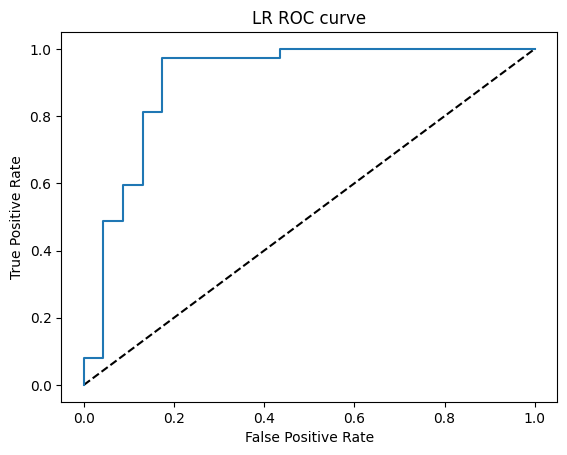

In [36]:
plt.plot([0,1], [0,1], "k--")
plt.plot(fpr,tpr,label = "Logistc Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LR ROC curve")
plt.show()

# Hyperparameter Tuning

In [37]:
lr = LogisticRegression()
penalty = ["l1", "l2"]
parameters = {"penalty":penalty}

lr_searcher = GridSearchCV(lr, parameters)

lr_searcher.fit(X_train, y_train)

GridSearchCV(estimator=LogisticRegression(),
             param_grid={'penalty': ['l1', 'l2']})

In [38]:
print(f"best parameters: {lr_searcher.best_params_}")

best parameters: {'penalty': 'l2'}


In [39]:
y_pred = lr_searcher.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_pred)}")

Test accuracy: 0.9


In [40]:
import joblib

final_model = LogisticRegression(penalty=lr_searcher.best_params_["penalty"])
final_model.fit(X_train, y_train)

artifact = {
    "model": final_model,
    "scaler": scaler,
    "numeric_features": numeric_list[:-1],     
    "feature_names": X_train.columns.tolist(),  
}
joblib.dump(artifact, "heart_attack_artifact.joblib")

['heart_attack_artifact.joblib']